<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/NA_Tatiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Criando dados simulados

In [49]:
from IPython.core.interactiveshell import dis
import pandas as pd
import numpy as np

# Define states and municipalities
states = {
    'São Paulo': ['A', 'B', 'C', 'D'],
    'Minas Gerais': ['X', 'Y'],
    'Rio de Janeiro': ['XXX', 'YYY'],
}

years = range(2000, 2022)

# Create an empty list to store data
data = []

# Generate simulated precipitation data
for state, municipalities in states.items():
    for municipality in municipalities:
        for year in years:
            # Simulate precipitation (e.g., between 500 and 2500 mm/year)
            precipitation = np.random.uniform(500, 2500)
            data.append({
                'Estado': state,
                'Município': municipality,
                'Ano': year,
                'Precipitação (mm)': precipitation
            })

# Create DataFrame
df = pd.DataFrame(data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             176 non-null    object 
 1   Município          176 non-null    object 
 2   Ano                176 non-null    int64  
 3   Precipitação (mm)  176 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.6+ KB
None


In [50]:
# quantos minicpios há por estado??
df.groupby('Estado')['Município'].nunique()


,Município
Estado,
Minas Gerais,2
Rio de Janeiro,2
São Paulo,4


In [51]:
# quantos municipios únicos há para cada estado?
df.groupby('Estado')['Município'].nunique()


,Município
Estado,
Minas Gerais,2
Rio de Janeiro,2
São Paulo,4


# Criando índices de dados faltantes

In [52]:
missing_indices = np.random.choice(df.index, size=int(len(df) * 0.1), replace=False)

print(missing_indices)

[144  90  32 105  43 126 161  87  44  53 159  91  28 162 151 149 172]


# Determinando se há dados faltantes no banco de dados

In [53]:
df.loc[missing_indices, 'Precipitação (mm)'] = np.nan
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             176 non-null    object 
 1   Município          176 non-null    object 
 2   Ano                176 non-null    int64  
 3   Precipitação (mm)  159 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.6+ KB
None


# Há dados faltantes por Estado, Município e Ano no conjunto de dados? (Específico)

In [54]:
missing_counts_summary = df[df['Precipitação (mm)'].isnull()].groupby(['Estado', 'Município', 'Ano']).size().reset_index(name='NA')

if not missing_counts_summary.empty:
    print("Tabela Resumo de Dados Faltantes por Estado, Município e Ano:")
    display(missing_counts_summary)
else:
    print("Não há dados faltantes por Estado, Município e Ano no conjunto de dados.")

Tabela Resumo de Dados Faltantes por Estado, Município e Ano:


,Estado,Município,Ano,NA
0,Minas Gerais,X,2002,1
1,Minas Gerais,X,2003,1
2,Minas Gerais,X,2017,1
3,Minas Gerais,Y,2016,1
4,Rio de Janeiro,XXX,2012,1
5,Rio de Janeiro,XXX,2017,1
6,Rio de Janeiro,XXX,2019,1
7,Rio de Janeiro,YYY,2005,1
8,Rio de Janeiro,YYY,2007,1
9,Rio de Janeiro,YYY,2008,1


# Há dados faltantes por Estado, Município e Ano no conjunto de dados? (Geral)

In [55]:
completion_counts = df.groupby(['Estado', 'Município'])['Precipitação (mm)'].agg(['count', 'size']).reset_index()
completion_counts['Porcentagem Completa (%)'] = (completion_counts['count'] / completion_counts['size']) * 100
completion_counts['Porcentagem Faltante (%)'] = 100 - completion_counts['Porcentagem Completa (%)']
completion_counts.rename(columns={'count': 'Dados Completos', 'size': 'Total Dados'}, inplace=True)

print("Porcentagem de Dados Completos e Faltantes por Estado e Município:")
display(completion_counts)

Porcentagem de Dados Completos e Faltantes por Estado e Município:


,Estado,Município,Dados Completos,Total Dados,Porcentagem Completa (%),Porcentagem Faltante (%)
0,Minas Gerais,X,19,22,86.363636,13.636364
1,Minas Gerais,Y,21,22,95.454545,4.545455
2,Rio de Janeiro,XXX,19,22,86.363636,13.636364
3,Rio de Janeiro,YYY,18,22,81.818182,18.181818
4,São Paulo,A,22,22,100.000000,0.000000
5,São Paulo,B,19,22,86.363636,13.636364
6,São Paulo,C,20,22,90.909091,9.090909
7,São Paulo,D,21,22,95.454545,4.545455


# Porcentagem de Dados Completos e Faltantes por Estado e Município

# Estados e Municípios sem dados faltantes

In [56]:
no_missing_data = completion_counts[completion_counts['Porcentagem Completa (%)'] > 95][['Estado', 'Município']]

if not no_missing_data.empty:
    print("Estados e Municípios com mais de 90% de dados completos:")
    display(no_missing_data)
else:
    print("Não há estados ou municípios com mais de 90% de dados completos.")

Estados e Municípios com mais de 90% de dados completos:


,Estado,Município
1,Minas Gerais,Y
4,São Paulo,A
7,São Paulo,D


In [57]:
# quantos municpios há por estado?
no_missing_data.groupby('Estado')['Município'].nunique()

,Município
Estado,
Minas Gerais,1
São Paulo,2


# Selecionando dados completos do banco de dados geral


In [59]:
df_complete = pd.merge(df, no_missing_data, on=['Estado', 'Município'], how='inner')

print(df_complete.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             66 non-null     object 
 1   Município          66 non-null     object 
 2   Ano                66 non-null     int64  
 3   Precipitação (mm)  64 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.2+ KB
None


In [60]:
# quantidade de dados completos por estado para cada um dos municipios considerando  a variavel Precipitação
df_complete.groupby(['Estado', 'Município'])['Precipitação (mm)'].count()


Estado        Município
Minas Gerais  Y            21
São Paulo     A            22
              D            21
Name: Precipitação (mm), dtype: int64

In [61]:
# faça resumo numérico da variavel Precipitação em função do estado para cada um dos municipios
df_complete.groupby(['Estado', 'Município'])['Precipitação (mm)'].describe()

count         mean         std         min  \
Estado       Município                                               
Minas Gerais Y           21.0  1566.084292  621.029402  575.025716   
São Paulo    A           22.0  1666.743725  648.145958  625.893160   
             D           21.0  1351.644549  563.795065  571.438730   

                                25%          50%          75%          max  
Estado       Município                                                      
Minas Gerais Y          1030.619415  1796.937251  2031.060954  2388.424646  
São Paulo    A          1088.668307  1835.839268  2247.089385  2489.329333  
             D           950.291930  1271.271243  1670.530045  2484.150979

In [74]:
missing_data_df_complete = df_complete[df_complete['Precipitação (mm)'].isnull()].groupby(['Estado', 'Município', 'Ano']).size().reset_index(name='NA')

if not missing_data_df_complete.empty:
    print("Dados Faltantes em df_complete por Estado, Município e Ano:")
    display(missing_data_df_complete)
else:
    print("Não há dados faltantes em df_complete por Estado, Município e Ano.")

Dados Faltantes em df_complete por Estado, Município e Ano:


,Estado,Município,Ano,NA
0,Minas Gerais,Y,2016,1
1,São Paulo,D,2021,1


In [63]:
unique_combinations = df_complete[['Estado', 'Município']].drop_duplicates()
print("Unique 'Estado' and 'Município' combinations in df_complete:")
display(unique_combinations)

Unique 'Estado' and 'Município' combinations in df_complete:


,Estado,Município
0,São Paulo,A
22,São Paulo,D
44,Minas Gerais,Y


In [64]:
print(f"Total de linhas no novo DataFrame: {len(df_complete)}")


Total de linhas no novo DataFrame: 66


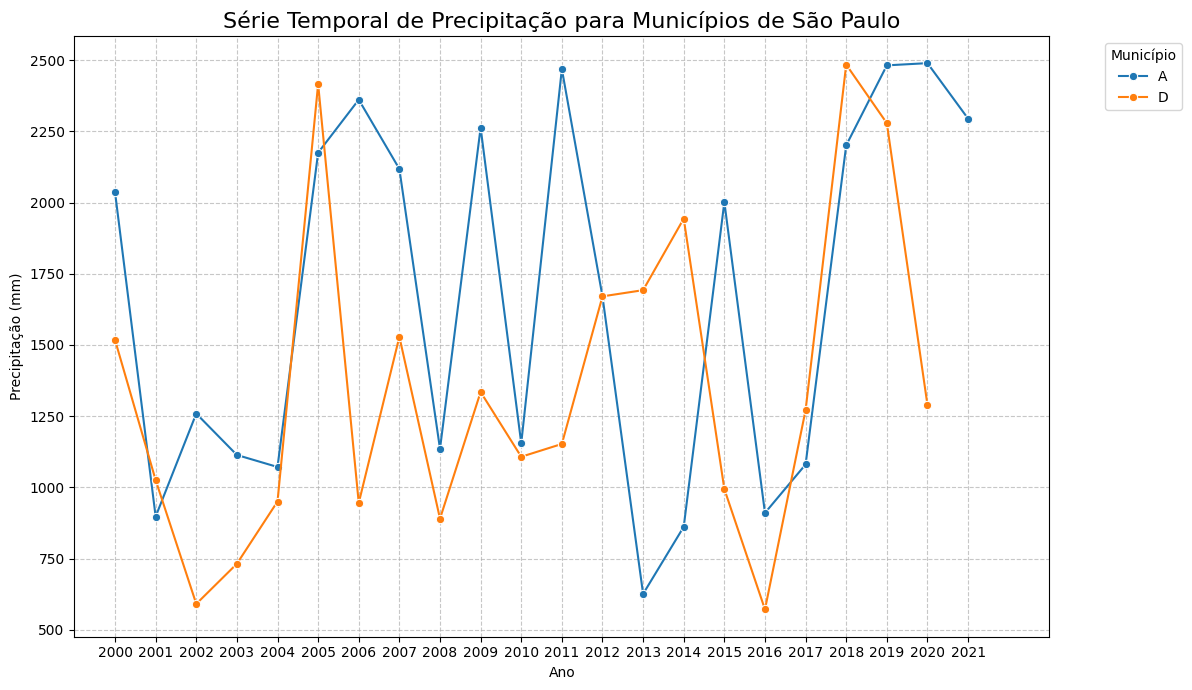

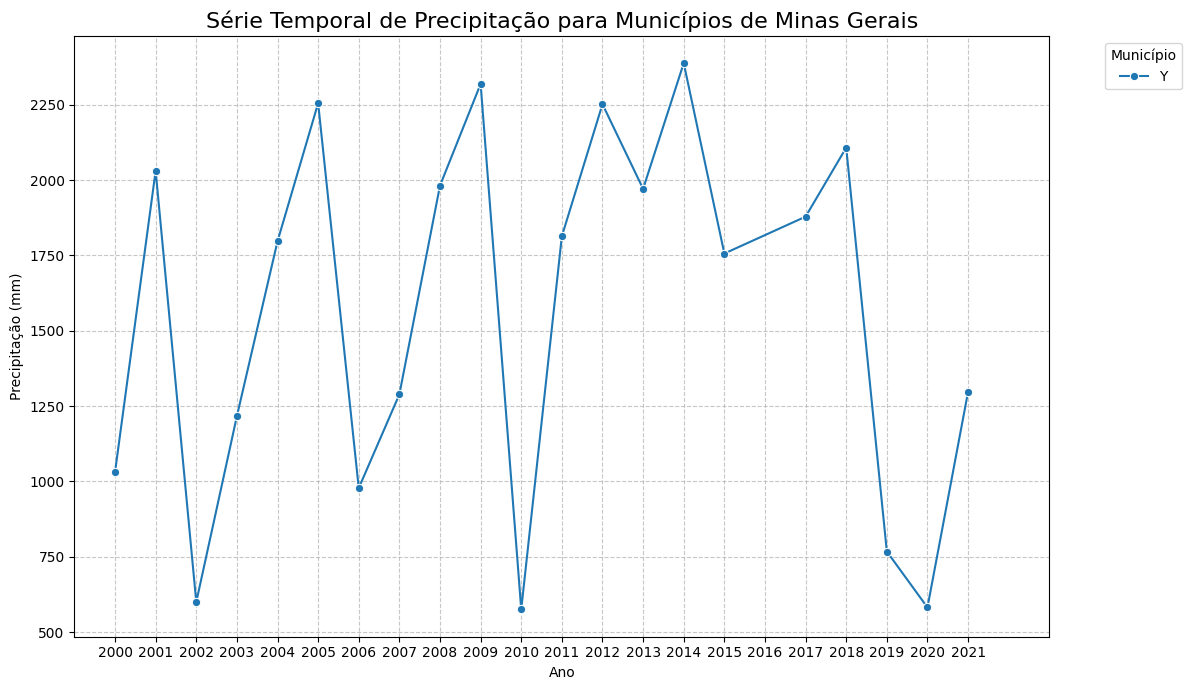

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a lista de estados únicos do DataFrame df_complete
states_in_df_complete = df_complete['Estado'].unique()

# Iterar sobre cada estado e gerar o gráfico de série temporal
for state in states_in_df_complete:
    # Filtrar o DataFrame para o estado atual
    df_state = df_complete[df_complete['Estado'] == state].copy()

    # Verificar se há dados para o estado antes de plotar
    if not df_state.empty:
        plt.figure(figsize=(12, 7))
        sns.lineplot(
            data=df_state,
            x="Ano",
            y="Precipitação (mm)",
            hue="Município",
            marker='o',
            palette='tab10'
        )

        plt.title(f"Série Temporal de Precipitação para Municípios de {state}", fontsize=16)
        plt.xlabel("Ano")
        plt.ylabel("Precipitação (mm)")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(title="Município", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xlim(1999, 2023) # Set x-axis limits
        plt.xticks(range(2000, 2022, 1)) # Set x-axis ticks for every year
        plt.tight_layout()
        plt.show()
    else:
        print(f"Não há dados completos para o estado de {state} em df_complete para gerar o gráfico.")